## Analyze of protocol Compound V3
[Link](https://defillama.com/protocol/compound-v3) on DeFiLlama

Author: Pudovikov Andrey

DeFi EDA

Conduct EDA for one of the top-50 DeFi protocols listed on DeFiLlama, using
the data collection tools studied in the workshop:

- Etherscan
- DeFiLlama
- The Graph
- CoinGecko
- GeckoTerminal
- Dune Analytics
- web3.py
Use at least 4 of these tools to gather historical data about the chosen
protocol's metrics, its token, and market performance. Construct relevant
metrics and graphs for your chosen protocol, compare it with market
competitors, and provide conclusions based on your analysis.

Choose one of the following protocol types:
- DEX (PancakeSwap, Curve, Balancer, Sushiswap)
- Lending (Aave, Compound, Venus, Morpho)
- Derivatives (GMX, Hyperliquid, dYdX)
- Staking (Lido, Solv, Renzo)
- Bridges (Stargate)

For example, for a DEX platform, you could construct the following metrics:
- TVL (Total Value Locked)
- Trading volumes
- Number of liquidity pools
- Token market capitalization
- Total token supply
- Trading volumes of top pools
- Supported blockchains

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import numpy as np
import time

### API DeFiLlama

In [2]:
# Base URL for DeFi Llama API
BASE_URL = "https://api.llama.fi"

# Function to get protocol data
def get_protocol_data(protocol_slug="compound-v3"):
    response = requests.get(f"{BASE_URL}/protocol/{protocol_slug}")
    return response.json()

# Function to get fees and revenue data
def get_fees_data(protocol_slug="compound-v3"):
    response = requests.get(f"{BASE_URL}/summary/fees/{protocol_slug}")
    return response.json()

# Get the data
protocol_data = get_protocol_data()
fees_data = get_fees_data()

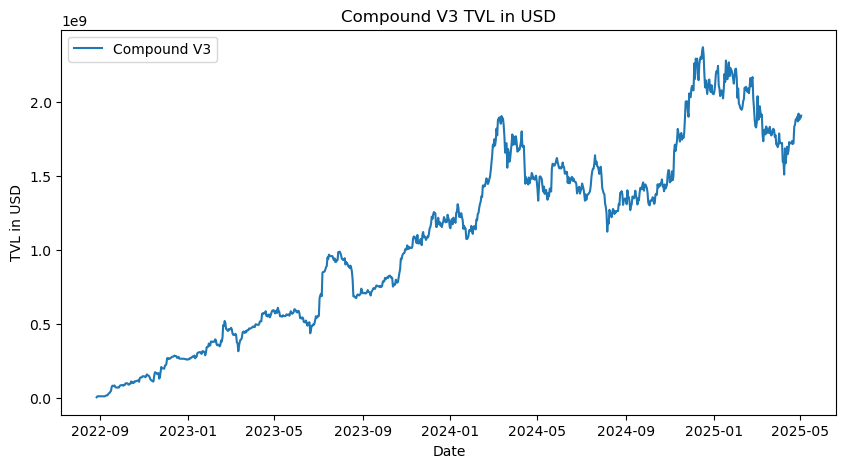

In [3]:
tvl = pd.DataFrame(protocol_data["tvl"])
tvl["date"] = pd.to_datetime(tvl["date"], unit='s')
tvl = tvl.set_index("date")

plt.figure(figsize=(10, 5))
plt.plot(tvl.index, tvl["totalLiquidityUSD"], label="Compound V3")
plt.title("Compound V3 TVL in USD")
plt.xlabel("Date")
plt.ylabel("TVL in USD")
plt.legend()
plt.show()


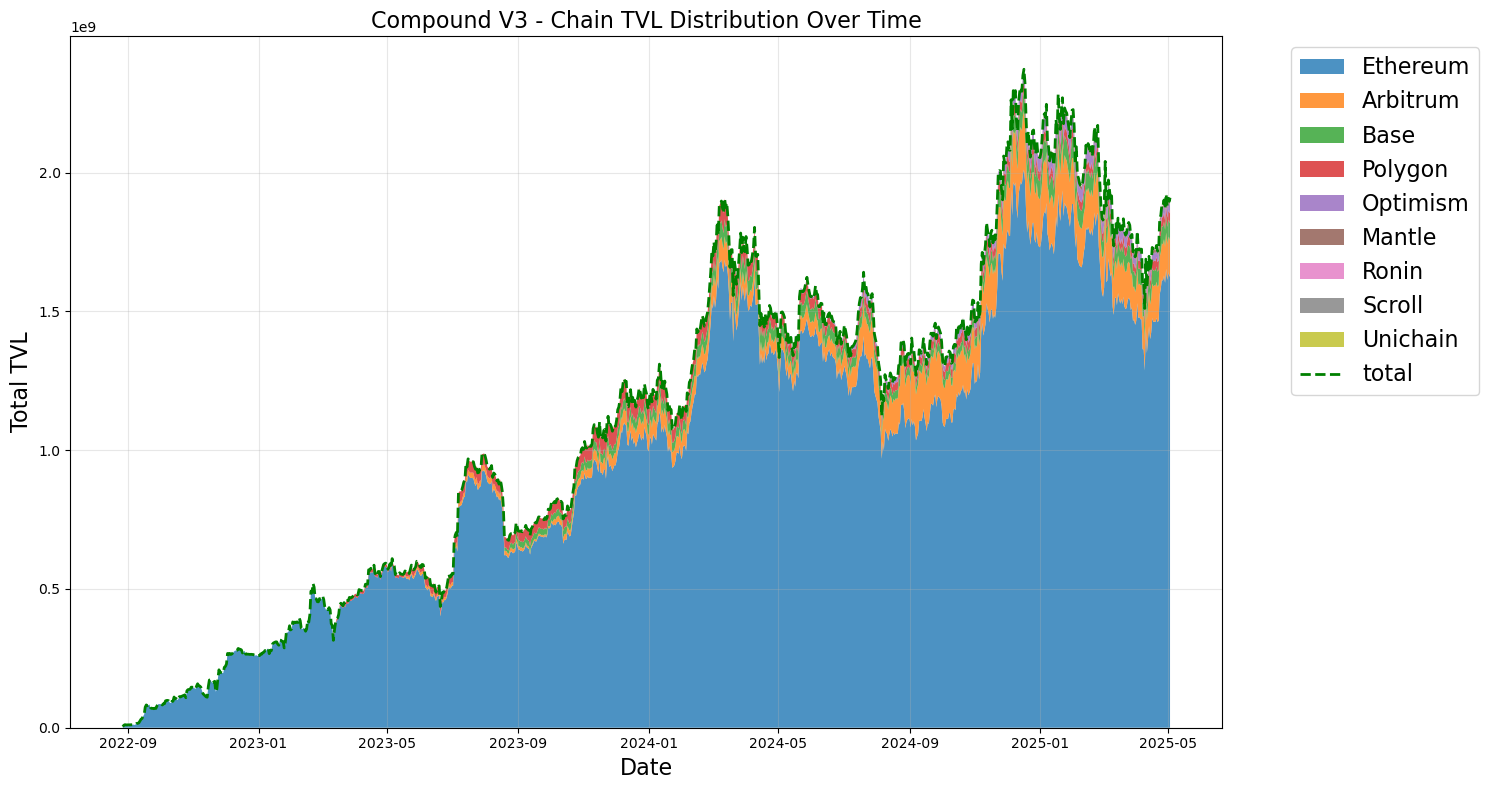

In [18]:
# tvl = tvl.set_index("date")
compare_chains = pd.DataFrame(index=tvl.index)
for chain in ['Ethereum', 'Unichain', 'Scroll', 'Base', 'Arbitrum',
               'Ronin', 'Polygon', 'Optimism', 'Mantle']:
    df = pd.DataFrame(protocol_data["chainTvls"][chain]["tvl"])
    df["date"] = pd.to_datetime(df["date"], unit='s')
    df = df.set_index("date")
    df = df.rename(columns={"totalLiquidityUSD": chain})

    compare_chains = compare_chains.join(df, how="left", lsuffix="_left", rsuffix="_right")

compare_chains = compare_chains.fillna(0)

# Define font size variable
FONT_SIZE = 16

plt.figure(figsize=(15, 8))

# Sort columns by their latest values for better visualization
sorted_columns = compare_chains.iloc[-1].sort_values(ascending=False).index

# Create stacked area plot
plt.stackplot(compare_chains.index, 
                [compare_chains[col] for col in sorted_columns],
                labels=sorted_columns,
                alpha=0.8)
plt.plot(tvl.index, tvl["totalLiquidityUSD"], label="total", color="green", linewidth=2, linestyle="--")

plt.title("Compound V3 - Chain TVL Distribution Over Time", fontsize=FONT_SIZE)
plt.xlabel("Date", fontsize=FONT_SIZE)
plt.ylabel("Total TVL", fontsize=FONT_SIZE)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=FONT_SIZE)
plt.grid(True, alpha=0.3)
plt.tight_layout()


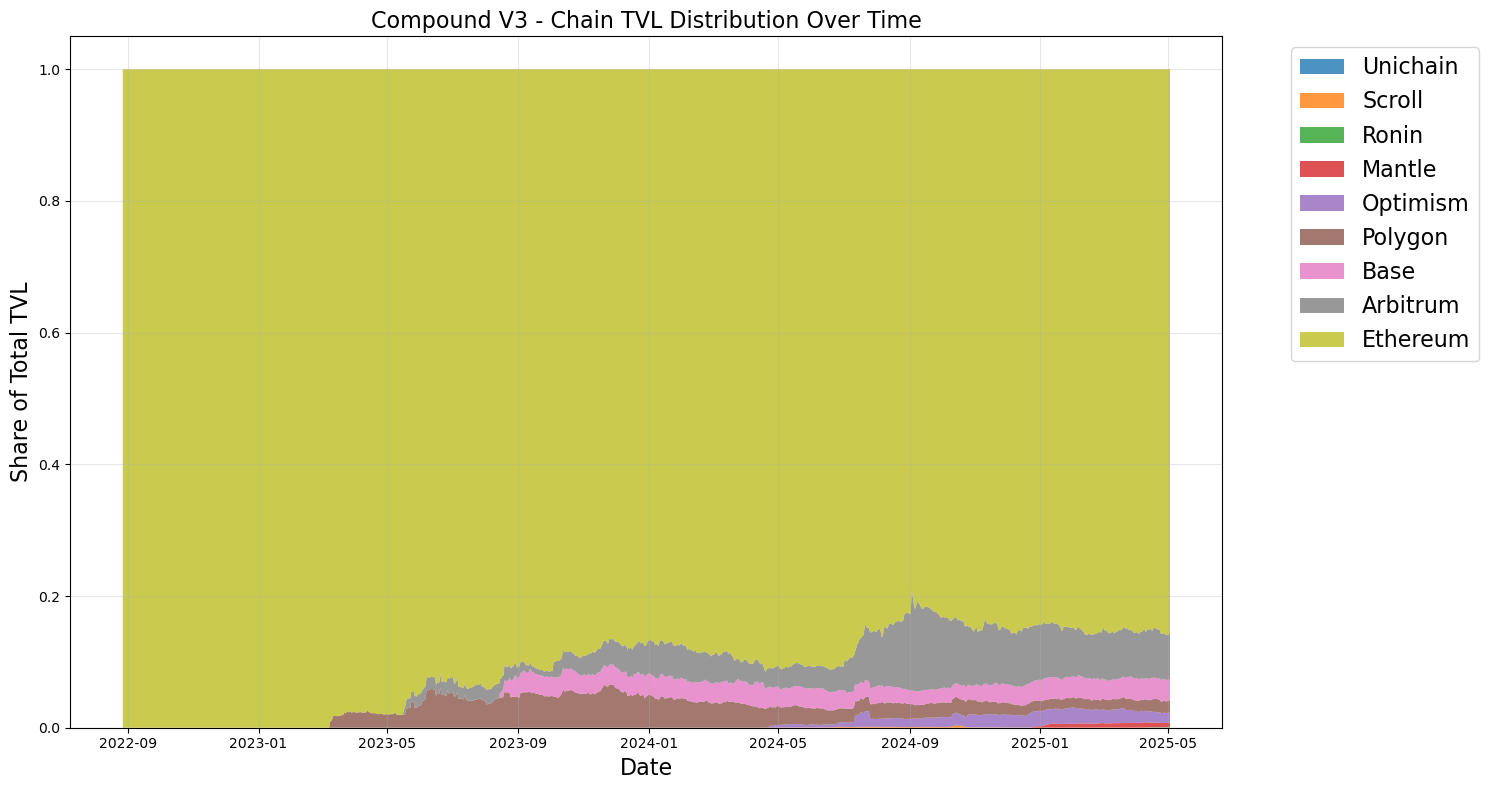

In [6]:
# Define font size variable
FONT_SIZE = 16

chain_rates = compare_chains.copy()

for chain in chain_rates.columns:
    chain_rates[chain] = chain_rates[chain] / tvl["totalLiquidityUSD"]

plt.figure(figsize=(15, 8))

# Sort columns by their latest values for better visualization
sorted_columns = chain_rates.iloc[-1].sort_values(ascending=True).index

# Create stacked area plot
plt.stackplot(chain_rates.index, 
                [chain_rates[col] for col in sorted_columns],
                labels=sorted_columns,
                alpha=0.8)

plt.title("Compound V3 - Chain TVL Distribution Over Time", fontsize=FONT_SIZE)
plt.xlabel("Date", fontsize=FONT_SIZE)
plt.ylabel("Share of Total TVL", fontsize=FONT_SIZE)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=FONT_SIZE)
plt.grid(True, alpha=0.3)
plt.tight_layout()


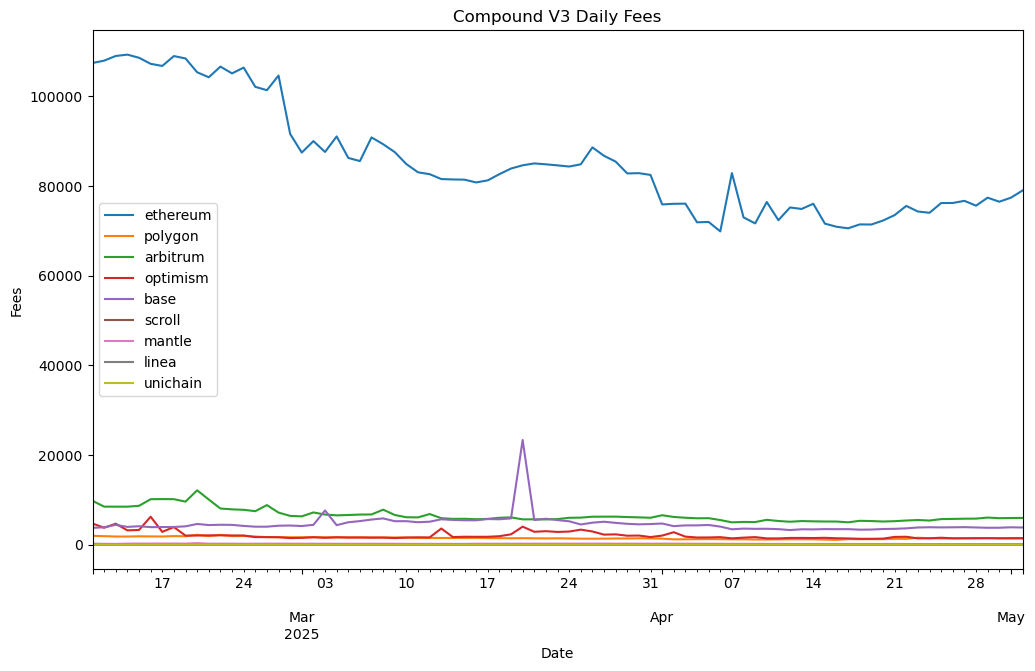

In [49]:
dates = pd.to_datetime(np.array([a[0] for a in fees_data["totalDataChartBreakdown"]]), unit='s')

fees = [{key: value['Compound V3'] for key, value in one_date[1].items()} for one_date in fees_data["totalDataChartBreakdown"]]

total_fees = pd.DataFrame(index=dates, data=fees).fillna(0)
total_fees.plot(figsize=(12, 7))
plt.title("Compound V3 Daily Fees")
plt.xlabel("Date")
plt.ylabel("Fees")
plt.legend()
plt.show()



Overall, my plots are similar to the plots provided on the DeFiLlama. [Distribution in TVL](https://defillama.com/protocol/compound-v3#tvl-charts), [daily distribution of fees by chains](https://defillama.com/protocol/compound-v3#fees-revenue). Also, the distrubution of rates is unique to my work, however it is similar to the 

### CoinGecko

Price data by [CoinGecko](https://www.coingecko.com
)

In [52]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [140]:
class CoinGeckoAPI:
    def __init__(self):
        self.api_key = os.getenv('COINGEKKO_API_KEY')
        if not self.api_key:
            raise ValueError("COINGEKKO_API_KEY not found in .env file")
        
        self.base_url = "https://api.coingecko.com/api/v3"
        self.headers = {
            "x-cg-demo-api-key": self.api_key
        }

    def get_historical_data(self, coin_id, days=30):
        """Get historical price data for a coin"""
        endpoint = f"{self.base_url}/coins/{coin_id}/market_chart"
        params = {
            'vs_currency': 'usd',
            'days': days
        }
        response = requests.get(endpoint, headers=self.headers, params=params)
        return response.json()
    
    def get_exchanges_prices(self, coin_id, vs_currencies='usd'):
        """Get prices of a coin on different exhanges"""
        endpoint = f"{self.base_url}/coins/{coin_id}/tickers"
        params = {
            'vs_currencies': vs_currencies
        }
        response = requests.get(endpoint, headers=self.headers, params=params)
        return response.json()


Historical Data (last 7 days):


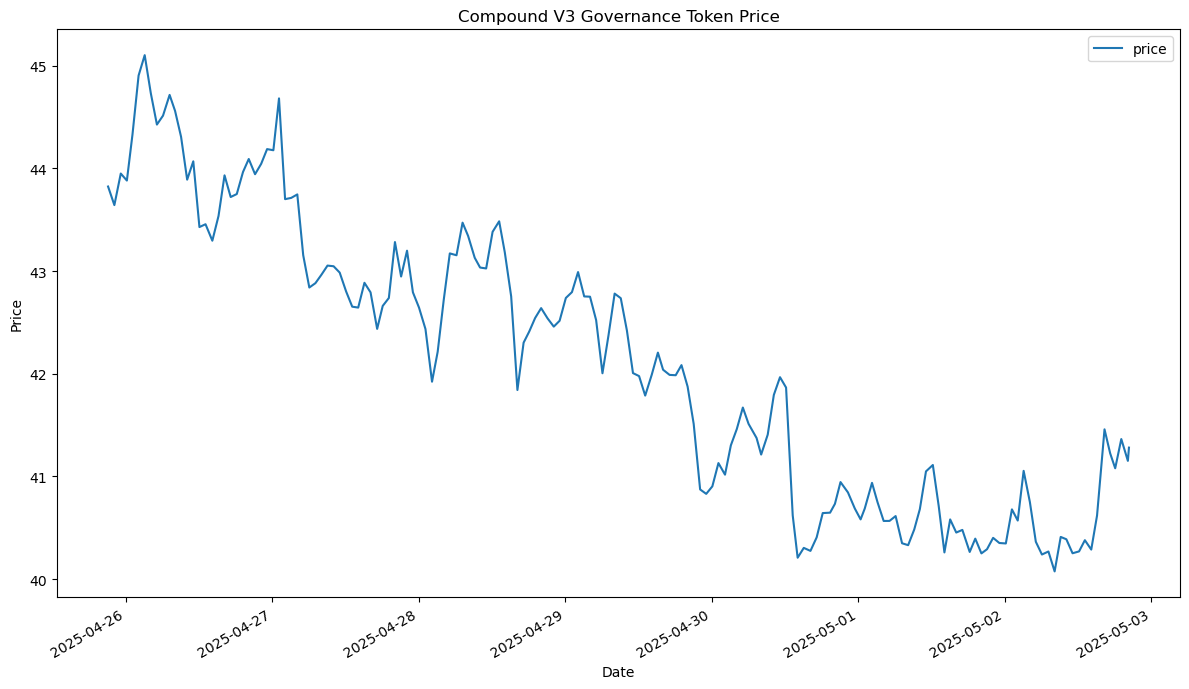

In [ ]:
cg = CoinGeckoAPI()

btc_historical = cg.get_historical_data('compound-governance-token', days=7)

df = pd.DataFrame(btc_historical['prices'], columns=['timestamp', 'price'])
df.index = pd.to_datetime(df['timestamp'], unit='ms')

df['price'].plot(figsize=(12, 7))
plt.title("Compound V3 Governance Token Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


This plot fully corresponds with the plot from [coingekko](https://www.coingecko.com/en/coins/compound)

In [ ]:
cg = CoinGeckoAPI()

compound_prices = cg.get_exchanges_prices('compound-governance-token', vs_currencies='usd')

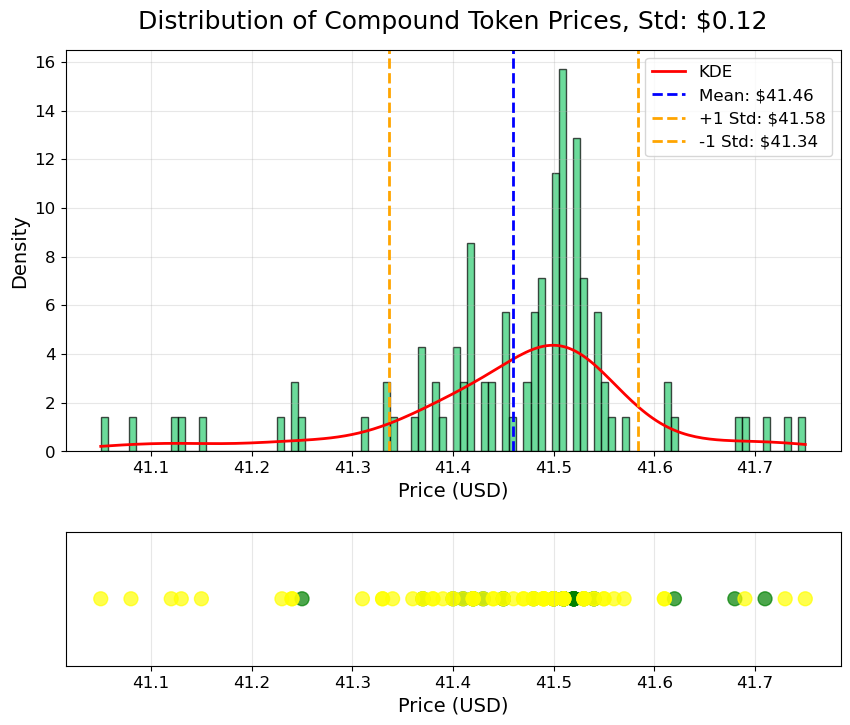

In [163]:
# Define font sizes as parameters
TITLE_FONTSIZE = 18
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12
LEGEND_FONTSIZE = 12

prices = [market["converted_last"]['usd'] for market in compound_prices['tickers']]
trust_scores = [market["trust_score"] for market in compound_prices['tickers']]

prices = np.array(prices)

# Calculate mean and standard deviation
mean_price = np.mean(prices)
std_price = np.std(prices)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[3, 1], gridspec_kw={'hspace': 0.3})

# Main histogram plot
ax1.hist(prices, bins=100, color='#2ecc71', alpha=0.7, edgecolor='black', density=True)
ax1.set_title(f'Distribution of Compound Token Prices, Std: ${std_price:.2f}', fontsize=TITLE_FONTSIZE, pad=15)
ax1.set_xlabel('Price (USD)', fontsize=LABEL_FONTSIZE)
ax1.set_ylabel('Density', fontsize=LABEL_FONTSIZE)
ax1.grid(True, alpha=0.3)

# Add KDE
from scipy import stats
kde = stats.gaussian_kde(prices)
x_range = np.linspace(prices.min(), prices.max(), 200)
ax1.plot(x_range, kde(x_range), color='red', linewidth=2, label='KDE')

# Add vertical lines for mean and std
ax1.axvline(x=mean_price, color='blue', linestyle='--', linewidth=2, label=f'Mean: ${mean_price:.2f}')
ax1.axvline(x=mean_price + std_price, color='orange', linestyle='--', linewidth=2, label=f'+1 Std: ${mean_price + std_price:.2f}')
ax1.axvline(x=mean_price - std_price, color='orange', linestyle='--', linewidth=2, label=f'-1 Std: ${mean_price - std_price:.2f}')

ax1.legend(fontsize=LEGEND_FONTSIZE)
ax1.tick_params(axis='both', labelsize=TICK_FONTSIZE)

# Trust score dots plot
ax2.scatter(prices, [0.5] * len(prices), c=trust_scores, alpha=0.7, s=100)
ax2.set_xlim(ax1.get_xlim())  # Match x-axis limits with histogram
ax2.set_yticks([])  # Remove y-axis ticks
ax2.set_xlabel('Price (USD)', fontsize=LABEL_FONTSIZE)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', labelsize=TICK_FONTSIZE)

# plt.tight_layout()
plt.show()

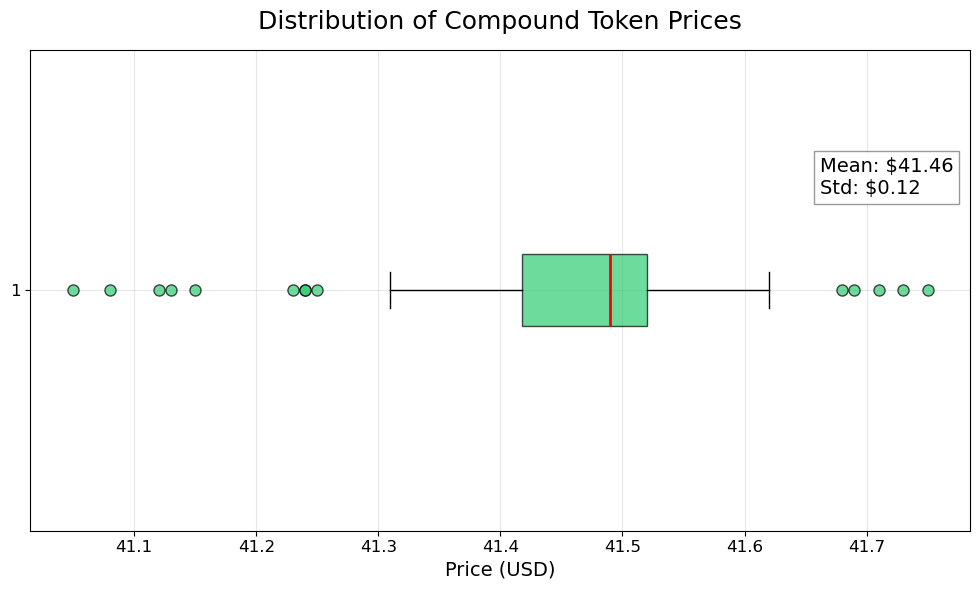

In [164]:
# Define font sizes as parameters
TITLE_FONTSIZE = 18
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12
LEGEND_FONTSIZE = 12

prices = [market["converted_last"]['usd'] for market in compound_prices['tickers']]
# Calculate mean and standard deviation
mean_price = np.mean(prices)
std_price = np.std(prices)

plt.figure(figsize=(10, 6))
box = plt.boxplot(prices, vert=False, patch_artist=True, 
                 boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(color='black'),
                 capprops=dict(color='black'),
                 flierprops=dict(marker='o', markerfacecolor='#2ecc71', markersize=8, alpha=0.7))

plt.title('Distribution of Compound Token Prices', fontsize=TITLE_FONTSIZE, pad=15)
plt.xlabel('Price (USD)', fontsize=LABEL_FONTSIZE)
plt.grid(True, alpha=0.3)

# Add mean line
# plt.axvline(x=mean_price, color='blue', linestyle='--', linewidth=2, label=f'Mean: ${mean_price:.2f}')

# Add mean and std text
plt.text(0.84, 0.7, f'Mean: ${mean_price:.2f}\nStd: ${std_price:.2f}', 
         transform=plt.gca().transAxes, fontsize=LABEL_FONTSIZE,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# plt.legend(fontsize=LEGEND_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.tight_layout()
plt.show()

So, here you can find some unique plots about distribution of price on different exchenges.

### Etherscan

In [228]:
load_dotenv()

class CompoundAnalyzer:
    def __init__(self):
        self.api_key = os.getenv('ETHERSCAN_API_KEY')
        if not self.api_key:
            raise ValueError("ETHERSCAN_API_KEY not found in .env file")
        
        self.base_url = "https://api.etherscan.io/api"
        self.compound_address = "0xc00e94Cb662C3520282E6f5717214004A7f26888"  # COMP token address
        self.rate_limit_delay = 0.2  # 200ms delay between requests

    def _make_request(self, params):
        """Make API request with rate limiting"""
        time.sleep(self.rate_limit_delay)
        response = requests.get(self.base_url, params=params)
        return response.json()

    def get_contract_transactions(self, start_block=0, end_block=99999999, page=1, offset=10000):
        """Get contract transactions with pagination"""
        params = {
            'module': 'account',
            'action': 'txlist',
            'address': self.compound_address,
            'startblock': start_block,
            'endblock': end_block,
            'page': page,
            # 'offset': offset,
            'sort': 'asc',
            'apikey': self.api_key
        }
        return self._make_request(params)

    def get_all_transactions(self):
        """Get all transactions for the COMP token address using pagination"""
        all_transactions = []
        page = 1
        while True:
            response = self.get_contract_transactions(page=page)
            if response['status'] != '1' or not response['result']:
                break
            all_transactions.extend(response['result'].copy())
            if len(response['result']) < 10000:  # Last page
                break
            page += 1
            print(f"Page {page} have been processed")
            if page > 15:
                break
        return all_transactions

In [229]:
analyzer = CompoundAnalyzer()

# Get protocol activity
print("\nAnalyzing Compound Protocol Activity...")
activity = analyzer.get_all_transactions()
print("\nProtocol Activity Summary:")


Analyzing Compound Protocol Activity...
Page 2 have been processed
Page 3 have been processed
Page 4 have been processed
Page 5 have been processed
Page 6 have been processed
Page 7 have been processed
Page 8 have been processed
Page 9 have been processed
Page 10 have been processed
Page 11 have been processed
Page 12 have been processed
Page 13 have been processed
Page 14 have been processed
Page 15 have been processed
Page 16 have been processed

Protocol Activity Summary:


In [292]:
transactions = pd.DataFrame([{'timeStamp': res["timeStamp"], 'functionName': res["functionName"]} for res in activity])
transactions['timeStamp'] = pd.to_datetime([res["timeStamp"] for res in activity], unit='s').date
print(transactions.head())
print(transactions.shape)

/var/folders/h0/trvv8z394996dlnpplvsqfb80000gn/T/ipykernel_10748/3515531288.py:2: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  transactions['timeStamp'] = pd.to_datetime([res["timeStamp"] for res in activity], unit='s').date


    timeStamp                                       functionName
0  2020-03-04  atInversebrah(int248 a, uint48[] b, uint32 c, ...
1  2020-03-06              transfer(address _to, uint256 _value)
2  2020-03-09              transfer(address _to, uint256 _value)
3  2020-03-09              transfer(address _to, uint256 _value)
4  2020-03-09              transfer(address _to, uint256 _value)
(150000, 2)


In [281]:
stats = transactions.groupby('timeStamp')['functionName'].value_counts().reset_index()
stats.head()

,timeStamp,functionName,count
0,2020-03-04,"atInversebrah(int248 a, uint48[] b, uint32 c, ...",15
1,2020-03-06,"transfer(address _to, uint256 _value)",15
2,2020-03-09,"transfer(address _to, uint256 _value)",45
3,2020-03-11,delegate(address to),15
4,2020-03-12,delegate(address to),15


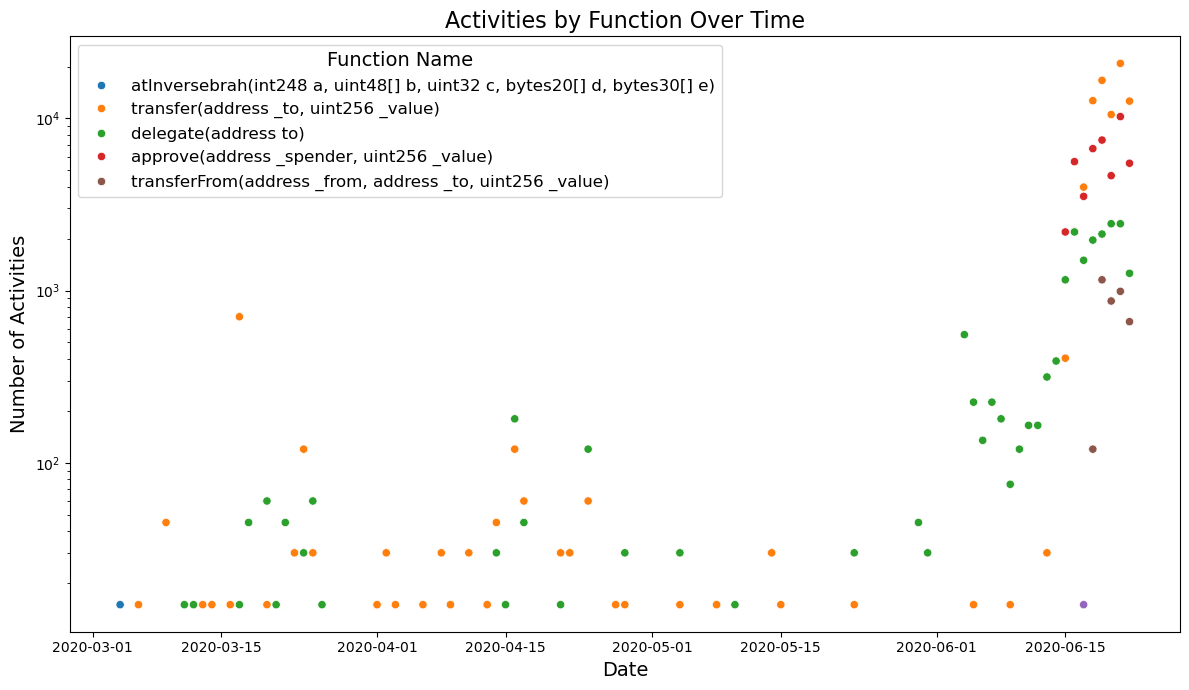

In [290]:
import seaborn as sns

FONTSIZE = 14  # Define fontsize variable

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=stats,
    x='timeStamp',
    y='count',
    hue='functionName',
    palette='tab10'
)
plt.xlabel('Date', fontsize=FONTSIZE)
plt.ylabel('Number of Activities', fontsize=FONTSIZE)
plt.title('Activities by Function Over Time', fontsize=FONTSIZE+2)
plt.legend(title='Function Name', title_fontsize=FONTSIZE, fontsize=FONTSIZE-2)
plt.yscale('log')  # Set y-axis to logarithmic scale
plt.tight_layout()
plt.show()

I limit total number of requestes, because it will take a lot of time, but this data describes the number of called functions of the contract for COMP token. The 150000 logs are used to create this plot.

### Web3py

In [ ]:
# !pip install web3

In [2]:
from web3 import Web3, HTTPProvider
from pprint import pprint

ETH_HTTP_NODE = 'https://ethereum-rpc.publicnode.com'

In [3]:
w3_http = Web3(HTTPProvider(ETH_HTTP_NODE))
w3_http.is_connected()


True

In [4]:
from abis import ERC_20_ABI

COMP_ADDRESS = '0xc00e94Cb662C3520282E6f5717214004A7f26888'
comp_contract = w3_http.eth.contract(address=COMP_ADDRESS, abi=ERC_20_ABI)


In [5]:
last_block_number = w3_http.eth.block_number
comp_transfer_logs = comp_contract.events.Transfer.get_logs(from_block=last_block_number-50000, to_block=last_block_number)


In [12]:
transfers = np.array([int(log['args']['value']) for log in comp_transfer_logs], dtype=float)

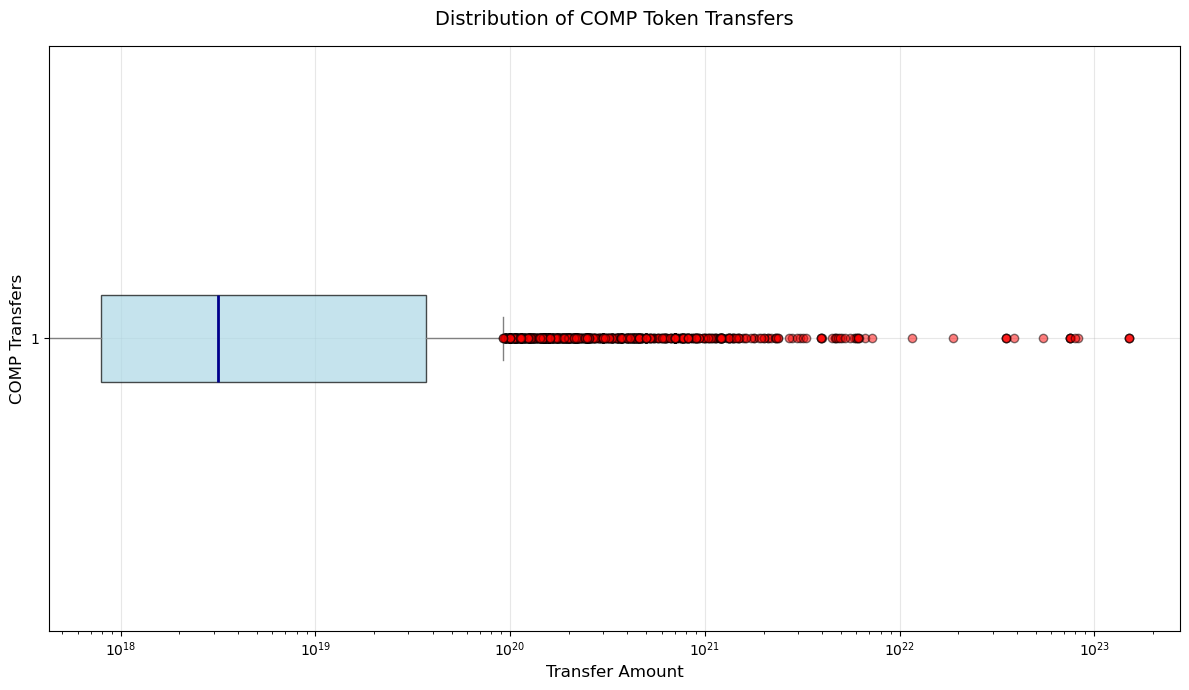

In [18]:
plt.figure(figsize=(12, 7))
plt.boxplot(transfers, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='darkblue', linewidth=2),
            whiskerprops=dict(color='gray', linestyle='-'),
            capprops=dict(color='gray'),
            flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5))
plt.title('Distribution of COMP Token Transfers', fontsize=14, pad=15)
plt.xlabel('Transfer Amount', fontsize=12)
plt.ylabel('COMP Transfers', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xscale('log')  # Add log scale for x-axis
plt.tight_layout()

### Result

I have analized the Compound protocol via four different tools - API DeFiLlama, API CoinGecko, API Etherscan, web3py interface